In [1]:
!pip install timm einops scikit-image gradio --quiet
print('Dependencies installed.')

Dependencies installed.


In [1]:
import os, math, time, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast
import torchvision.transforms as transforms

from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

# ── Reproducibility ──
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
set_seed(42)

# ── Device ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpus = torch.cuda.device_count()
print(f'Device : {device}  |  GPUs : {n_gpus}')
for i in range(n_gpus):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

Device : cuda  |  GPUs : 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [9]:
class TinyImageNetDataset(Dataset):
    def __init__(self, root, split='train', transform=None):
        self.root = Path(root)
        self.split = split
        self.transform = transform
        self.samples = []
        self.class_to_idx = {}
        self._load()

    def _load(self):
        train_dir = self.root / 'train'
        classes = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
        self.class_to_idx = {c: i for i, c in enumerate(classes)}

        if self.split == 'train':
            for cls in classes:
                for p in (train_dir / cls / 'images').glob('*.JPEG'):
                    self.samples.append((str(p), self.class_to_idx[cls]))
        else:
            val_dir = self.root / 'val'
            ann_file = val_dir / 'val_annotations.txt'
            img2cls = {}
            if ann_file.exists():
                for line in ann_file.read_text().splitlines():
                    parts = line.split('\t')
                    img2cls[parts[0]] = parts[1]
            for p in (val_dir / 'images').glob('*.JPEG'):
                cls = img2cls.get(p.name, classes[0])
                self.samples.append((str(p), self.class_to_idx.get(cls, 0)))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label


IMAGE_SIZE = 224
DATASET_ROOT = '/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200'

train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

train_ds = TinyImageNetDataset(DATASET_ROOT, 'train', train_tf)
val_ds   = TinyImageNetDataset(DATASET_ROOT, 'val',   val_tf)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f'Train: {len(train_ds):,} images | {len(train_loader):,} batches')
print(f'Val  : {len(val_ds):,} images  | {len(val_loader):,} batches')

Train: 100,000 images | 781 batches
Val  : 10,000 images  | 79 batches


In [10]:
# ── 2-D Sinusoidal Positional Encoding ──────────────────────────
def get_2d_sincos_pos_embed(embed_dim, grid_size, cls_token=False):
    grid = np.stack(np.meshgrid(
        np.arange(grid_size, dtype=np.float32),
        np.arange(grid_size, dtype=np.float32)
    ), axis=0).reshape(2, -1)   # [2, N]

    def _emb(pos, d):
        omega = np.arange(d//2, dtype=np.float32) / (d/2)
        omega = 1.0 / (10000 ** omega)
        out   = np.einsum('n,d->nd', pos, omega)
        return np.concatenate([np.sin(out), np.cos(out)], axis=1)

    half = embed_dim // 2
    pos_emb = np.concatenate([_emb(grid[1], half), _emb(grid[0], half)], axis=1)
    if cls_token:
        pos_emb = np.concatenate([np.zeros([1, embed_dim]), pos_emb], axis=0)
    return pos_emb


# ── Multi-Head Self-Attention ────────────────────────────────────
class MHSA(nn.Module):
    def __init__(self, dim, heads, drop=0.):
        super().__init__()
        self.h    = heads
        self.dh   = dim // heads
        self.sc   = self.dh ** -0.5
        self.qkv  = nn.Linear(dim, dim*3)
        self.proj = nn.Linear(dim, dim)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        B, N, C = x.shape
        q, k, v = self.qkv(x).reshape(B, N, 3, self.h, self.dh).permute(2,0,3,1,4).unbind(0)
        attn = self.drop((q @ k.transpose(-2,-1)) * self.sc).softmax(-1)
        return self.proj((attn @ v).transpose(1,2).reshape(B, N, C))


# ── MLP Block ────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, dim, ratio=4., drop=0.):
        super().__init__()
        h = int(dim * ratio)
        self.net = nn.Sequential(
            nn.Linear(dim, h), nn.GELU(), nn.Dropout(drop),
            nn.Linear(h, dim),             nn.Dropout(drop),
        )
    def forward(self, x): return self.net(x)


# ── Transformer Block ────────────────────────────────────────────
class TBlock(nn.Module):
    def __init__(self, dim, heads, ratio=4., drop=0.):
        super().__init__()
        self.n1 = nn.LayerNorm(dim)
        self.attn = MHSA(dim, heads, drop)
        self.n2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, ratio, drop)
    def forward(self, x):
        x = x + self.attn(self.n1(x))
        x = x + self.mlp(self.n2(x))
        return x

print('Transformer building blocks ready')

Transformer building blocks ready


In [11]:
class PatchEmbed(nn.Module):
    """
    Splits 224×224 image into 16×16 patches → 196 patches.
    Projects each patch (16*16*3=768 raw pixels) to embed_dim.
    """
    def __init__(self, img_size=224, patch_size=16, in_ch=3, dim=768):
        super().__init__()
        self.n = (img_size // patch_size) ** 2   # 196
        self.proj = nn.Conv2d(in_ch, dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)   # [B, N, D]


def random_masking(x, mask_ratio=0.75):
    """
    Randomly mask (mask_ratio) fraction of patches.
    Returns:
      x_vis       [B, N_vis, D]  — 25% visible patches
      mask        [B, N]         — 1=masked, 0=visible
      ids_restore [B, N]         — inverse permutation
    """
    B, N, D = x.shape
    keep = int(N * (1 - mask_ratio))   # 49 patches kept

    noise       = torch.rand(B, N, device=x.device)
    ids_shuf    = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuf, dim=1)

    ids_keep = ids_shuf[:, :keep]
    x_vis    = torch.gather(x, 1, ids_keep.unsqueeze(-1).expand(-1,-1,D))

    mask = torch.ones(B, N, device=x.device)
    mask[:, :keep] = 0
    mask = torch.gather(mask, 1, ids_restore)

    return x_vis, mask, ids_restore


# Quick test
pe = PatchEmbed()
dummy_img = torch.randn(2, 3, 224, 224)
patches = pe(dummy_img)                          # [2, 196, 768]
vis, msk, rst = random_masking(patches, 0.75)    # [2, 49, 768]
print(f'Image → Patches : {tuple(patches.shape)}')
print(f'Visible patches : {tuple(vis.shape)}  (25% of 196 = 49)')
print(f'Masked  patches : {int(msk.sum(1).mean().item())} per image (75%)')

Image → Patches : (2, 196, 768)
Visible patches : (2, 49, 768)  (25% of 196 = 49)
Masked  patches : 147 per image (75%)


In [12]:
class MAEEncoder(nn.Module):

    def __init__(self, img_size=224, patch_size=16, in_ch=3,
                 dim=768, depth=12, heads=12, mlp_ratio=4.):
        super().__init__()

        self.patch_embed = PatchEmbed(img_size, patch_size, in_ch, dim)
        N = self.patch_embed.n   # number of patches (196 for 224x224)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))

        # positional embedding (not trained)
        self.register_buffer('pos_embed', torch.zeros(1, N + 1, dim))

        # transformer blocks
        self.blocks = nn.ModuleList(
            [TBlock(dim, heads, mlp_ratio) for _ in range(depth)]
        )

        self.norm = nn.LayerNorm(dim)

        self._init()

    def _init(self):
        # create 2D sin-cos positional embeddings
        g = int(self.patch_embed.n ** 0.5)

        pe = get_2d_sincos_pos_embed(
            self.pos_embed.shape[-1], g, cls_token=True
        )

        self.pos_embed.data.copy_(
            torch.from_numpy(pe).float().unsqueeze(0)
        )

        # initialize CLS token
        nn.init.normal_(self.cls_token, std=0.02)

        # proper initialization function
        def init_weights(m):
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        # apply to all modules
        self.apply(init_weights)

    def forward(self, x, mask_ratio=0.75):

        # Step 1 — patch embedding
        x = self.patch_embed(x)              # [B, N, D]

        # add positional embedding
        x = x + self.pos_embed[:, 1:, :]

        # Step 2 — random masking
        x, mask, ids_restore = random_masking(x, mask_ratio)

        # Step 3 — add CLS token
        cls = (self.cls_token + self.pos_embed[:, :1, :]).expand(
            x.shape[0], -1, -1
        )

        x = torch.cat([cls, x], dim=1)       # [B, 1+N_visible, D]

        # Step 4 — transformer blocks
        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)

        return x, mask, ids_restore


# test encoder
_enc = MAEEncoder()

print(
    f'Encoder params: {sum(p.numel() for p in _enc.parameters())/1e6:.1f}M'
)

del _enc

Encoder params: 85.6M


In [13]:


class MAEDecoder(nn.Module):
    """
    Lightweight ViT-Small decoder.
    Config: dim=384, depth=12, heads=6 → ~22M params
    """
    def __init__(self, num_patches=196, patch_size=16,
                 enc_dim=768, dec_dim=384, depth=12, heads=6,
                 mlp_ratio=4., in_ch=3):
        super().__init__()
        self.dec_dim     = dec_dim
        self.num_patches = num_patches

        # Project encoder → decoder dimension
        self.enc2dec = nn.Linear(enc_dim, dec_dim)

        # Learnable mask token (replaces missing patches)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, dec_dim))

        self.register_buffer('pos_embed', torch.zeros(1, num_patches+1, dec_dim))

        self.blocks = nn.ModuleList([TBlock(dec_dim, heads, mlp_ratio) for _ in range(depth)])
        self.norm   = nn.LayerNorm(dec_dim)

        # Pixel prediction head: each token → p*p*3 pixel values
        self.head = nn.Linear(dec_dim, patch_size * patch_size * in_ch)

        self._init()

    def _init(self):
        g = int(self.num_patches**0.5)
        pe = get_2d_sincos_pos_embed(self.dec_dim, g, cls_token=True)
        self.pos_embed.data.copy_(torch.from_numpy(pe).float().unsqueeze(0))
        nn.init.normal_(self.mask_token, std=0.02)

        # Proper initialization function (fixes boolean error)
        def init_weights(m):
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        self.apply(init_weights)

    def forward(self, latent, ids_restore):
        """
        latent      : [B, 1+N_vis, enc_dim]
        ids_restore : [B, N]
        Returns pred: [B, N, p*p*3]
        """
        B, D = latent.shape[0], self.dec_dim
        N    = self.num_patches

        # Project to decoder dim
        x     = self.enc2dec(latent)               # [B, 1+N_vis, D]
        N_vis = x.shape[1] - 1

        # Build full sequence: visible + mask tokens, then unshuffle
        mtok  = self.mask_token.expand(B, N - N_vis, -1)
        full  = torch.cat([x[:, 1:], mtok], dim=1)  # [B, N, D]
        full  = torch.gather(full, 1,
                             ids_restore.unsqueeze(-1).expand(-1, -1, D))  # restore order

        # Re-add CLS and positional embeddings
        x = torch.cat([x[:, :1], full], dim=1)    # [B, 1+N, D]
        x = x + self.pos_embed

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)
        return self.head(x[:, 1:])   # [B, N, p*p*3]  — drop CLS


# Test decoder
_dec = MAEDecoder()
print(f'Decoder params: {sum(p.numel() for p in _dec.parameters())/1e6:.1f}M')
del _dec

Decoder params: 21.9M


In [14]:
class MAE(nn.Module):
    """
    Masked Autoencoder (He et al., 2022).
    Asymmetric: large ViT-Base encoder + lightweight ViT-Small decoder.
    """
    def __init__(self, img_size=224, patch_size=16, in_ch=3,
                 enc_dim=768, enc_depth=12, enc_heads=12,
                 dec_dim=384, dec_depth=12, dec_heads=6,
                 mask_ratio=0.75, norm_pix_loss=True):
        super().__init__()
        self.patch_size    = patch_size
        self.mask_ratio    = mask_ratio
        self.norm_pix_loss = norm_pix_loss
        num_patches        = (img_size // patch_size) ** 2   # 196

        self.encoder = MAEEncoder(img_size, patch_size, in_ch, enc_dim, enc_depth, enc_heads)
        self.decoder = MAEDecoder(num_patches, patch_size, enc_dim, dec_dim, dec_depth, dec_heads, in_ch=in_ch)

    # ── Helpers ──────────────────────────────────────────────────
    def patchify(self, imgs):
        """[B,3,H,W] → [B, N, p*p*3]"""
        p = self.patch_size
        B, C, H, W = imgs.shape
        h, w = H//p, W//p
        x = imgs.reshape(B, C, h, p, w, p).permute(0,2,4,3,5,1)
        return x.reshape(B, h*w, p*p*C)

    def unpatchify(self, x):
        """[B, N, p*p*3] → [B, 3, H, W]"""
        p = self.patch_size
        B, N, _ = x.shape
        h = w = int(N**0.5)
        return x.reshape(B, h, w, p, p, 3).permute(0,5,1,3,2,4).reshape(B,3,h*p,w*p)

    # ── MSE Loss on masked patches only ──────────────────────────
    def compute_loss(self, imgs, pred, mask):
        target = self.patchify(imgs)   # [B, N, p*p*3]
        if self.norm_pix_loss:
            mean   = target.mean(-1, keepdim=True)
            var    = target.var(-1,  keepdim=True)
            target = (target - mean) / (var + 1e-6).sqrt()
        loss = ((pred - target)**2).mean(-1)   # [B, N]
        return (loss * mask).sum() / mask.sum()

    # ── Forward Pass ─────────────────────────────────────────────
    def forward(self, imgs, mask_ratio=None):
        """
        Part 2 forward pass:
          1. Pass visible patches to encoder
          2. Project encoder output to decoder dimension  (in decoder)
          3. Append learnable mask tokens                 (in decoder)
          4. Apply decoder transformer
          5. Reconstruct pixel patches via linear head
          6. Compute MSE loss on masked patches only
        """
        if mask_ratio is None: mask_ratio = self.mask_ratio
        latent, mask, ids_restore = self.encoder(imgs, mask_ratio)
        pred  = self.decoder(latent, ids_restore)
        loss  = self.compute_loss(imgs, pred, mask)
        return loss, pred, mask


# ── Param count ──────────────────────────────────────────────────
model = MAE()
enc_p = sum(p.numel() for p in model.encoder.parameters())
dec_p = sum(p.numel() for p in model.decoder.parameters())
tot_p = enc_p + dec_p
print(f'MAE params  — Encoder: {enc_p/1e6:.1f}M | Decoder: {dec_p/1e6:.1f}M | Total: {tot_p/1e6:.1f}M')

# Sanity forward pass
with torch.no_grad():
    loss, pred, mask = model(torch.randn(2,3,224,224))
print(f'Forward pass OK — loss={loss.item():.4f}, pred={tuple(pred.shape)}, masked={mask.float().mean():.0%}')

MAE params  — Encoder: 85.6M | Decoder: 21.9M | Total: 107.5M
Forward pass OK — loss=1.1522, pred=(2, 196, 768), masked=75%


In [15]:
NUM_EPOCHS    = 30
BASE_LR       = 2e-4
WEIGHT_DECAY  = 0.1
MASK_RATIO    = 0.75
GRAD_CLIP     = 1.0

EFF_LR = BASE_LR * BATCH_SIZE / 256  # linear LR scaling rule
print(f'Effective LR: {EFF_LR:.2e}')

# ── Multi-GPU model ───────────────────────────────────────────
model = MAE(mask_ratio=MASK_RATIO, norm_pix_loss=True)
if n_gpus > 1:
    print(f'Wrapping with DataParallel ({n_gpus} GPUs)')
    model = nn.DataParallel(model)
model = model.to(device)

# ── AdamW with selective weight decay ────────────────────────
decay, no_decay = [], []
for n, p in model.named_parameters():
    if not p.requires_grad: continue
    (no_decay if (p.ndim <= 1 or 'bias' in n) else decay).append(p)
optimizer = torch.optim.AdamW(
    [{'params': decay, 'weight_decay': WEIGHT_DECAY},
     {'params': no_decay, 'weight_decay': 0.0}],
    lr=EFF_LR, betas=(0.9, 0.95)
)

def lr_lambda(epoch):
    t = epoch / max(1, NUM_EPOCHS - 1)
    return max(1e-6 / EFF_LR, 0.5 * (1 + math.cos(math.pi * t)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ── Mixed Precision Scaler ────────────────────────────────────
scaler = GradScaler()

print('Optimizer, scheduler, scaler ready')

Effective LR: 1.00e-04
Wrapping with DataParallel (2 GPUs)
Optimizer, scheduler, scaler ready


In [16]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = float('inf')
        self.should_stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0          # improvement → reset
        else:
            self.counter += 1           # no improvement
            print(f'  EarlyStopping: no improvement for {self.counter}/{self.patience} epochs')
            if self.counter >= self.patience:
                self.should_stop = True

early_stop = EarlyStopping(patience=5, min_delta=1e-4)

In [17]:
CKPT_PATH   = '/kaggle/working/mae_best.pth'
train_losses, val_losses = [], []
best_val    = float('inf')

def _forward(model, imgs):
    if isinstance(model, nn.DataParallel):
        loss, pred, mask = model(imgs)
        return loss.mean(), pred, mask
    return model(imgs)

def train_epoch(model, loader, opt, scaler, ep):
    model.train(); total = 0.
    bar = tqdm(loader, desc=f'Ep {ep+1:03d} [train]', leave=False)
    for imgs, _ in bar:
        imgs = imgs.to(device, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with autocast(device_type='cuda'):
            loss, _, _ = _forward(model, imgs)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(opt); scaler.update()
        total += loss.item()
        bar.set_postfix(loss=f'{loss.item():.4f}')
    return total / len(loader)

@torch.no_grad()
def val_epoch(model, loader):
    model.eval(); total = 0.
    for imgs, _ in loader:
        imgs = imgs.to(device, non_blocking=True)
        with autocast(device_type='cuda'):
            loss, _, _ = _forward(model, imgs)
        total += loss.item()
    return total / len(loader)


print('Starting MAE training...')
t0 = time.time()

for ep in range(NUM_EPOCHS):
    tl = train_epoch(model, train_loader, optimizer, scaler, ep)
    vl = val_epoch(model, val_loader)
    scheduler.step()
    train_losses.append(tl); val_losses.append(vl)

    lr_now = scheduler.get_last_lr()[0]
    elapsed = (time.time()-t0)/60
    print(f'Ep {ep+1:03d}/{NUM_EPOCHS} | train={tl:.4f} | val={vl:.4f} | lr={lr_now:.2e} | {elapsed:.1f}min')

    if vl < best_val:
        best_val = vl
        sd = model.module.state_dict() if hasattr(model,'module') else model.state_dict()
        torch.save({'epoch':ep,'state_dict':sd,'val_loss':vl}, CKPT_PATH)
        print(f'  ✓ checkpoint saved  (val={vl:.4f})')
    early_stop.step(vl)
    if early_stop.should_stop:
        print(f'\n⏹ Early stopping triggered at epoch {ep+1}. Best val={early_stop.best_loss:.4f}')
        break

print(f'\nDone. Best val loss: {best_val:.4f}')

Starting MAE training...


Ep 001 [train]:   0%|          | 0/781 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Ep 001/30 | train=0.6711 | val=0.5984 | lr=9.97e-05 | 8.5min
  ✓ checkpoint saved  (val=0.5984)


Ep 002 [train]:   0%|          | 0/781 [00:00<?, ?it/s]

...

Ep 028/30 | train=0.3581 | val=0.3619 | lr=1.00e-06 | 205.8min
  ✓ checkpoint saved  (val=0.3619)


Ep 029 [train]:   0%|          | 0/781 [00:00<?, ?it/s]

Ep 029/30 | train=0.3580 | val=0.3620 | lr=1.00e-06 | 213.0min
  EarlyStopping: no improvement for 1/5 epochs


Ep 030 [train]:   0%|          | 0/781 [00:00<?, ?it/s]

Ep 030/30 | train=0.3580 | val=0.3616 | lr=1.00e-06 | 220.4min
  ✓ checkpoint saved  (val=0.3616)

Done. Best val loss: 0.3616


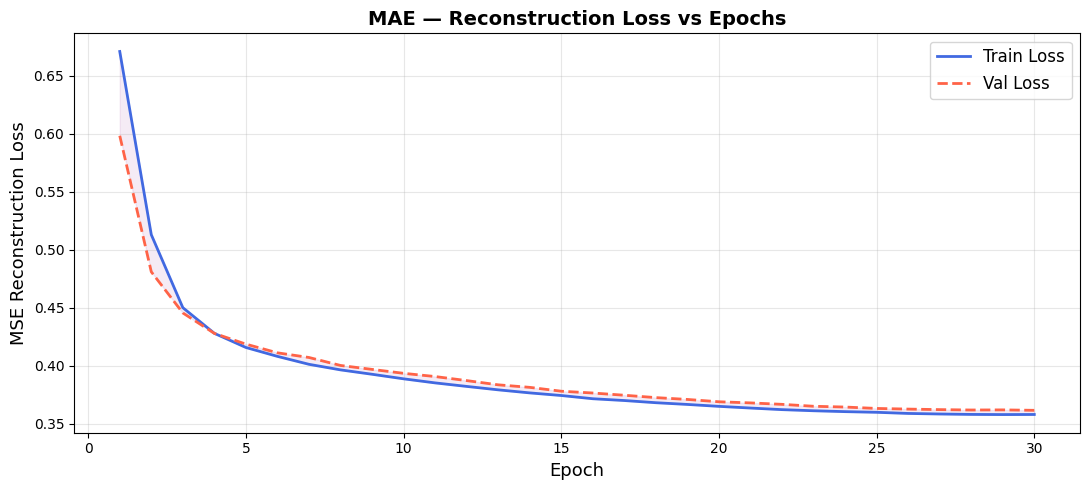

Final  → train=0.3580  val=0.3616


In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
eps = range(1, len(train_losses)+1)
ax.plot(eps, train_losses, label='Train Loss', color='royalblue', lw=2)
ax.plot(eps, val_losses,   label='Val Loss',   color='tomato',    lw=2, ls='--')
ax.fill_between(eps, train_losses, val_losses, alpha=0.08, color='purple')
ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('MSE Reconstruction Loss', fontsize=13)
ax.set_title('MAE — Reconstruction Loss vs Epochs', fontsize=14, fontweight='bold')
ax.legend(fontsize=12); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/loss_curve.png', dpi=150)
plt.show()
print(f'Final  → train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}')

Checkpoint loaded — epoch 30, val=0.3616


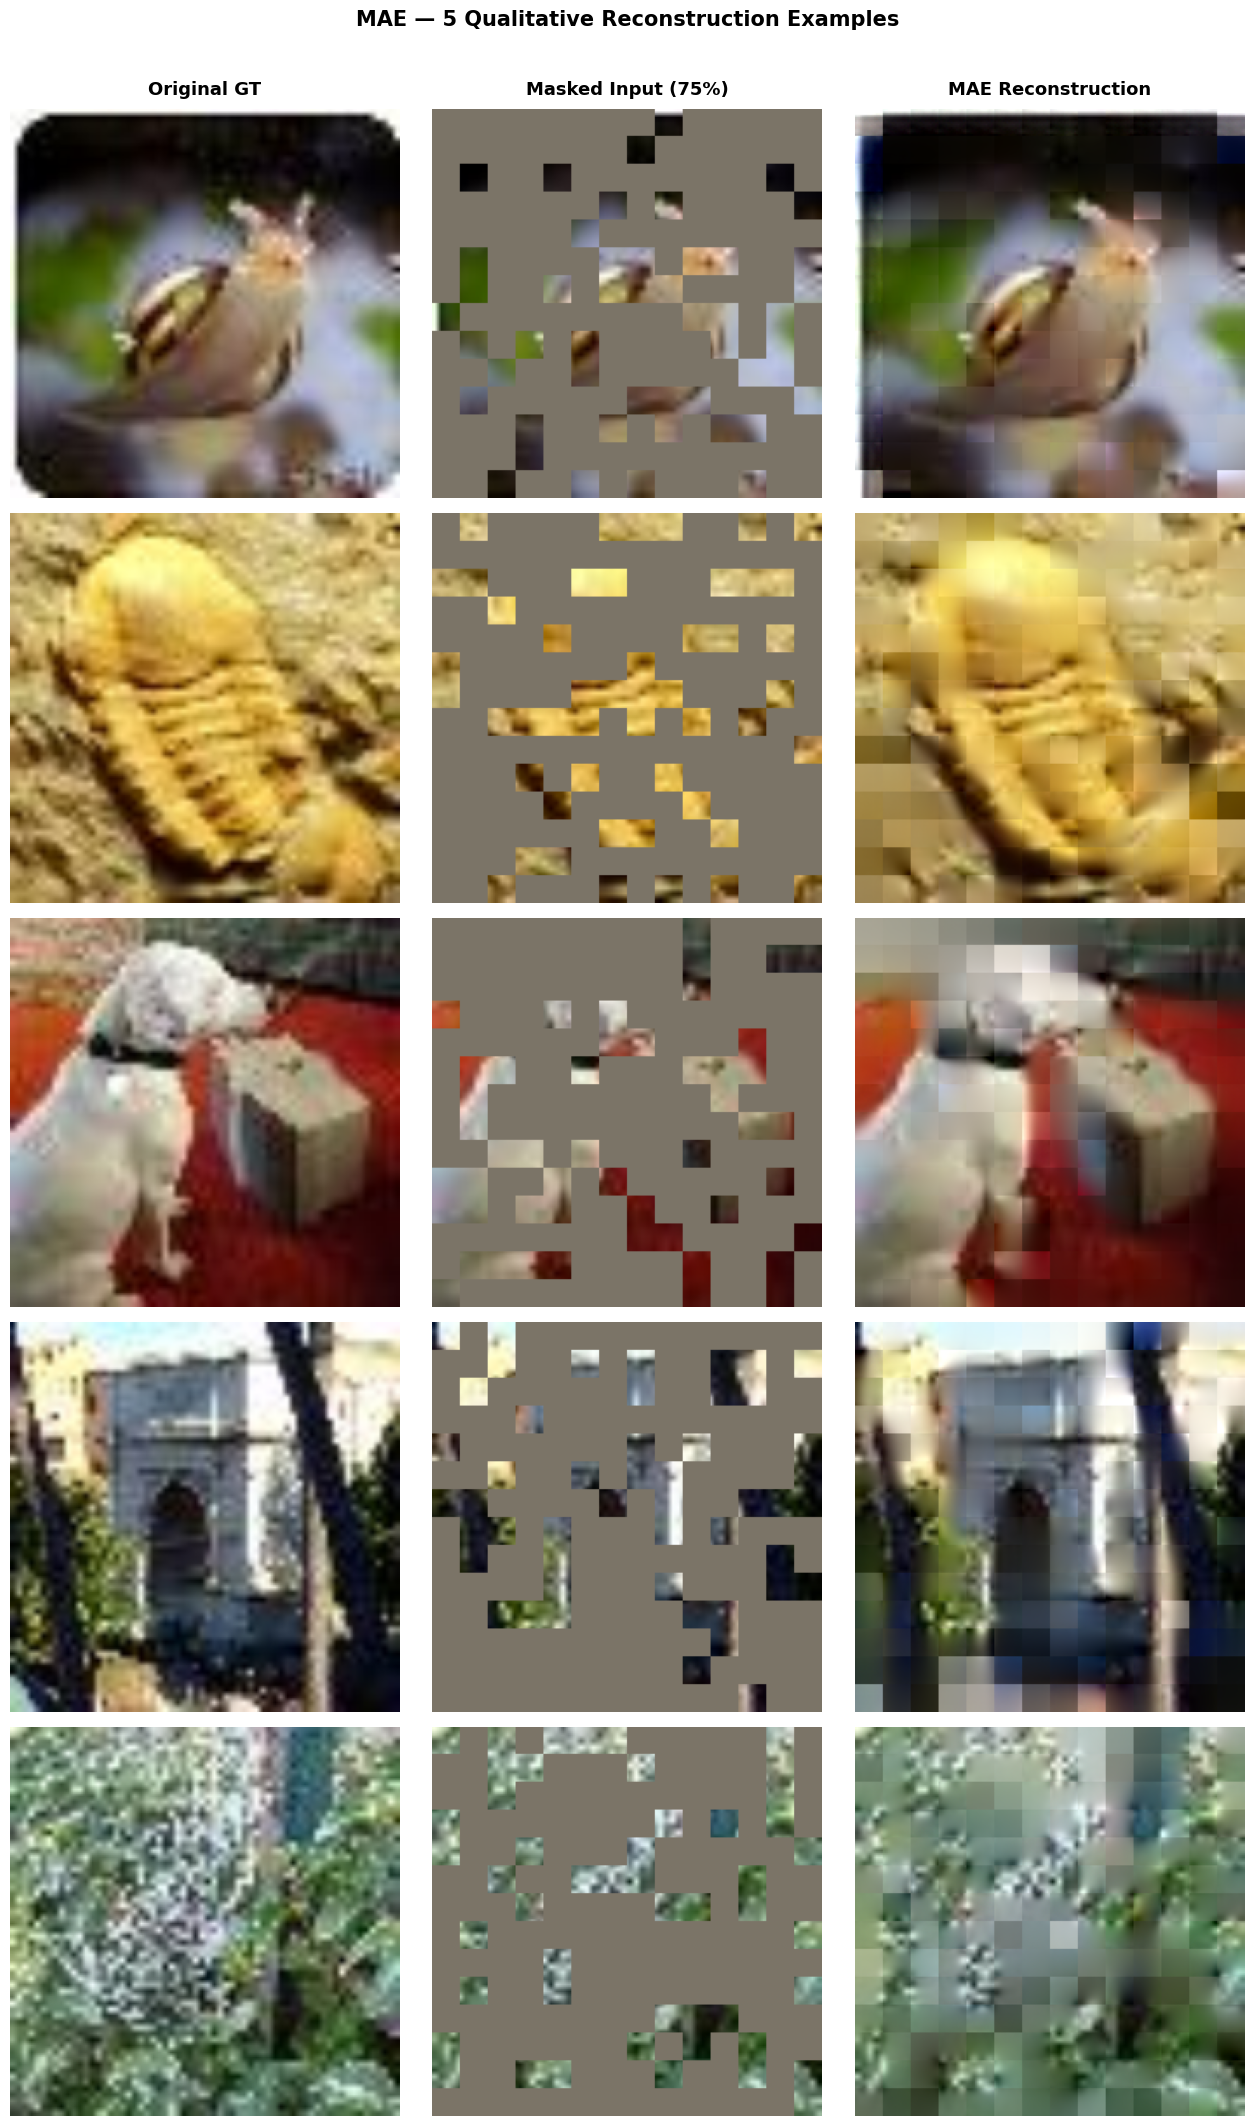

Visualization saved to /kaggle/working/reconstructions.png


In [21]:
# Load best weights
ckpt   = torch.load(CKPT_PATH, map_location=device)
vis_model = MAE(mask_ratio=MASK_RATIO, norm_pix_loss=True).to(device)
vis_model.load_state_dict(ckpt['state_dict'])
vis_model.eval()
print(f'Checkpoint loaded — epoch {ckpt["epoch"]+1}, val={ckpt["val_loss"]:.4f}')

MEAN = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
STD  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
denorm = lambda t: (t.cpu()*STD + MEAN).clamp(0,1)


@torch.no_grad()
def visualize(model, imgs_norm, mask_ratio=0.75, title='Reconstruction', save=None):
    imgs_norm = imgs_norm.to(device)
    with autocast(device_type='cuda'):
        _, pred, mask = model(imgs_norm, mask_ratio)

    B   = imgs_norm.shape[0]
    p   = model.patch_size
    po  = model.patchify(imgs_norm)              # [B,N,p*p*3]
    me  = mask.unsqueeze(-1).expand_as(po)       # [B,N,p*p*3]

    # Masked image
    m_img = denorm(model.unpatchify(po*(1-me)))  # visible patches only

    # Reconstructed image (invert per-patch normalisation)
    mean_t = po.mean(-1, keepdim=True)
    var_t  = po.var(-1,  keepdim=True)
    pred_u = pred*(var_t+1e-6).sqrt() + mean_t
    r_img  = denorm(model.unpatchify(po*(1-me) + pred_u*me))

    orig = denorm(imgs_norm)

    n = min(B, 5)
    fig, axes = plt.subplots(n, 3, figsize=(13, 4.2*n))
    if n==1: axes = axes[None]
    for c, col in enumerate(['Original GT','Masked Input (75%)','MAE Reconstruction']):
        axes[0,c].set_title(col, fontsize=13, fontweight='bold', pad=10)
    for i in range(n):
        for c, im in enumerate([orig[i], m_img[i], r_img[i]]):
            axes[i,c].imshow(im.permute(1,2,0).numpy())
            axes[i,c].axis('off')

    plt.suptitle(title, fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    if save: plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()
    return orig, m_img, r_img


samples, _ = next(iter(DataLoader(val_ds, batch_size=5, shuffle=True)))
orig, m_img, r_img = visualize(
    vis_model, samples, mask_ratio=0.75,
    title='MAE — 5 Qualitative Reconstruction Examples',
    save='/kaggle/working/reconstructions.png'
)
print('Visualization saved to /kaggle/working/reconstructions.png')

In [23]:
def img_metrics(gt, recon):
    """gt, recon: [B,3,H,W] float in [0,1]"""
    ps, ss = [], []
    for i in range(gt.shape[0]):
        g = gt[i].permute(1,2,0).numpy()
        r = recon[i].permute(1,2,0).numpy()
        ps.append(psnr_metric(g, r, data_range=1.))
        ss.append(ssim_metric(g, r, data_range=1., channel_axis=2, win_size=7))
    return np.array(ps), np.array(ss)


# ── 5 sample table ────────────────────────────────────────────
ps5, ss5 = img_metrics(orig, r_img)
print('─'*46)
print(f'{"Sample":<10}{"PSNR (dB)":>14}{"SSIM":>12}')
print('─'*46)
for i,(p,s) in enumerate(zip(ps5,ss5)):
    print(f'  {i+1:<8}{p:>14.2f}{s:>12.4f}')
print('─'*46)
print(f'  {"Mean":<8}{ps5.mean():>14.2f}{ss5.mean():>12.4f}')
print('─'*46)

# ── Extended eval on 100 val images ──────────────────────────
all_p, all_s = [], []
vis_model.eval()
eval_ld = DataLoader(val_ds, batch_size=20, shuffle=True, num_workers=2)
for bi, (imgs, _) in enumerate(eval_ld):
    if bi >= 5: break
    imgs = imgs.to(device)
    with torch.no_grad(), autocast(device_type='cuda'):
        _, pred, mask = vis_model(imgs)
    po  = vis_model.patchify(imgs)
    me  = mask.unsqueeze(-1).expand_as(po)
    mean_t, var_t = po.mean(-1,keepdim=True), po.var(-1,keepdim=True)
    pred_u = pred*(var_t+1e-6).sqrt()+mean_t
    ri = denorm(vis_model.unpatchify(po*(1-me)+pred_u*me))
    oi = denorm(imgs)
    pb, sb = img_metrics(oi.cpu(), ri.cpu())
    all_p.extend(pb); all_s.extend(sb)

print(f'\nExtended eval ({len(all_p)} images):')
print(f'  Mean PSNR : {np.mean(all_p):.2f} dB')
print(f'  Mean SSIM : {np.mean(all_s):.4f}')

──────────────────────────────────────────────
Sample         PSNR (dB)        SSIM
──────────────────────────────────────────────
  1                24.54      0.8273
  2                22.34      0.6381
  3                24.26      0.7319
  4                20.70      0.6305
  5                20.26      0.5122
──────────────────────────────────────────────
  Mean             22.42      0.6680
──────────────────────────────────────────────

Extended eval (100 images):
  Mean PSNR : 24.67 dB
  Mean SSIM : 0.7246


In [34]:
!pip install -q --upgrade gradio

In [35]:
import gradio as gr
import torch
from torch import amp
from torchvision import transforms
from PIL import Image
import numpy as np

infer_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    ),
])

# ---------- MAE inference ----------
@torch.no_grad()
def mae_inference(pil_img, mask_pct):
    """Gradio callback: image → (masked image, reconstruction, metrics)"""

    ratio = max(0.1, min(0.95, mask_pct/100.0))

    t = infer_tf(pil_img).unsqueeze(0).to(device)

    # mixed precision inference
    with amp.autocast(device_type='cuda'):
        _, pred, mask = vis_model(t, mask_ratio=ratio)

    # patchify input
    po = vis_model.patchify(t)

    # expand mask
    me = mask.unsqueeze(-1).expand_as(po)

    # unnormalize prediction
    mean_t = po.mean(-1, keepdim=True)
    var_t  = po.var(-1, keepdim=True)

    pred_u = pred * (var_t + 1e-6).sqrt() + mean_t

    # masked input
    masked = vis_model.unpatchify(po * (1 - me))

    # reconstruction
    recon = vis_model.unpatchify(po*(1-me) + pred_u*me)

    # convert to numpy
    m_np = denorm(masked).squeeze(0).permute(1,2,0).cpu().numpy()
    r_np = denorm(recon).squeeze(0).permute(1,2,0).cpu().numpy()
    o_np = denorm(t).squeeze(0).permute(1,2,0).cpu().numpy()

    # compute metrics
    ps = psnr_metric(o_np, r_np, data_range=1.)
    ss = ssim_metric(o_np, r_np, data_range=1., channel_axis=2, win_size=7)

    # convert numpy → PIL
    def to_pil(a):
        return Image.fromarray((a*255).clip(0,255).astype(np.uint8))

    return to_pil(m_np), to_pil(r_np), f"PSNR: {ps:.2f} dB   |   SSIM: {ss:.4f}"


with gr.Blocks(title="MAE Demo") as demo:

    gr.Markdown(
        """
        # 🎭 Masked Autoencoder (MAE) — Real-Time Reconstruction
        
        Upload an image and choose a masking ratio.  
        The model reconstructs the hidden patches.
        """
    )

    with gr.Row():

        with gr.Column(scale=1):

            inp = gr.Image(type="pil", label="Input Image")

            sl = gr.Slider(
                minimum=10,
                maximum=95,
                value=75,
                step=5,
                label="Masking Ratio (%)"
            )

            btn = gr.Button("Reconstruct ▶")

        with gr.Column(scale=2):

            with gr.Row():
                out_m = gr.Image(type="pil", label="Masked Input")
                out_r = gr.Image(type="pil", label="Reconstruction")

            metrics = gr.Textbox(label="Quality Metrics", interactive=False)

    # events
    btn.click(mae_inference, inputs=[inp, sl], outputs=[out_m, out_r, metrics])
    inp.change(mae_inference, inputs=[inp, sl], outputs=[out_m, out_r, metrics])
    sl.change(mae_inference, inputs=[inp, sl], outputs=[out_m, out_r, metrics])

    # example images
    examples = [
        [Image.open(val_ds.samples[i][0]), 75] for i in [0,1,2]
    ]

    gr.Examples(
        examples=examples,
        inputs=[inp, sl],
        label="Example Images from TinyImageNet"
    )


demo.launch(share=True)

print("Gradio app launched!")

* Running on local URL:  http://127.0.0.1:7868
* Running on public URL: https://a9144be05ab8e58512.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Gradio app launched!
